In [50]:
import numpy as np 
import matplotlib.pyplot as plt
import calc_op_em as coe
import h5py
from tqdm import tqdm

In [64]:
cube = h5py.File('/dat/milic/SUSI_modeling/extended_cube.h5','r')

In [65]:
T = cube['Temperature']

In [66]:
T.shape

(1024, 8333, 401)

In [67]:
Tt = T[:,:1024,:]

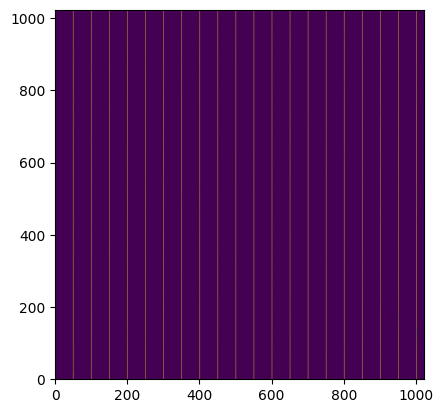

In [68]:
plt.imshow(Tt[:,:,0].T, origin='lower')

In [49]:
# Now we want to extract one vertical slice, for example at i = 0
# Let's quickly repack:
i = 0
z = 250


slice = []

# Let's make a ray of paramters:

for z in range(0, 401):
    param_ray = {
        'Temperature': cube['Temperature'][i,:,z],
        'Pressure': cube['Pressure'][i,:,z],
        'Electron_density': cube['Electron_density'][i,:,z],
        'LOS_velocity': cube['LOS_velocity'][i,:,z],
        'Population_lower_level': cube['Population_lower_level'][i,:,400-z]/1e6,
        'Population_upper_level': cube['Population_upper_level'][i,:,400-z]/1e6
    }
    slice.append(param_ray)

In [51]:
ll = np.linspace(393.0, 393.6, 601) # in nm

In [52]:
spectrum = np.zeros((len(slice), len(ll)))

for z in tqdm(range(len(slice))):

    op, em = coe.calc_op_em(slice[z], ll, take_given_S=False)
    spectrum_temp, tau, CR = coe.simple_formal_solution(op, op, 24.0e5)
    spectrum[z,:] = 1.0 - np.exp(-tau)

100%|██████████| 401/401 [07:51<00:00,  1.18s/it]


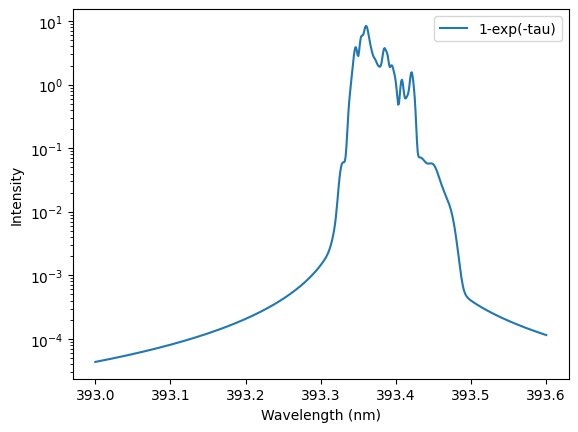

In [46]:
plt.semilogy(ll, tau, label='1-exp(-tau)')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.legend()
plt.show()

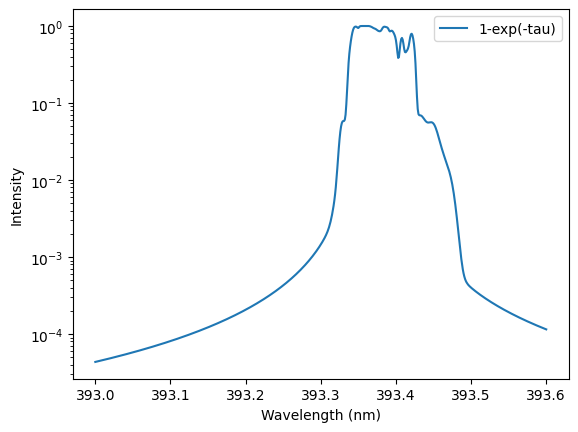

In [47]:
plt.semilogy(ll, 1-np.exp(-tau), label='1-exp(-tau)')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity')
plt.legend()
plt.show()

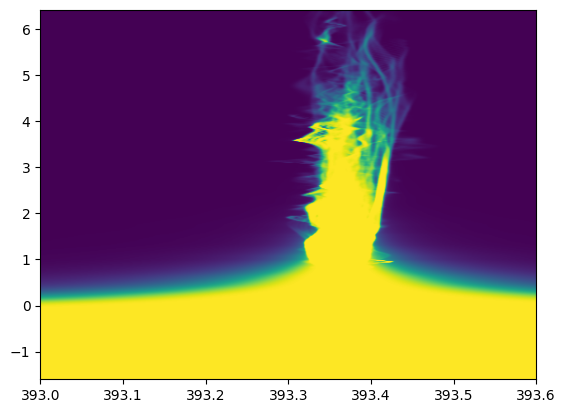

In [59]:
plt.imshow(spectrum, aspect='auto', extent=[ll[0], ll[-1], 0-1.6, len(slice)*0.02-1.6], origin='lower')

In [71]:
T = np.mean(cube['Temperature'][0,:,:], axis=(0))

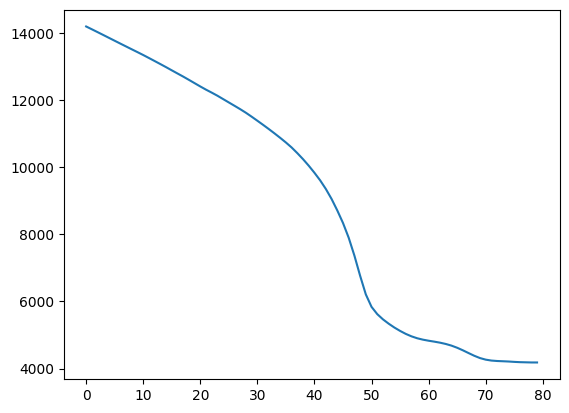

In [74]:
plt.plot(T[:80])